In [2]:
import json
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn
sklearn.set_config(enable_metadata_routing=True)

from sklearn.model_selection import PredefinedSplit
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report,
    f1_score,
    average_precision_score,
    precision_score,
    make_scorer,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

import optuna
from optuna_integration.sklearn import OptunaSearchCV
from optuna.distributions import FloatDistribution, IntDistribution

from xgboost import XGBClassifier

In [3]:
RANDOM_STATE = 42
DATA_DIR = "../../data/processed"
CLASSES = ['Backdoor', 'CommInj', 'DoS', 'Reconn', 'normal']

cols = json.load(open(f"{DATA_DIR}/feature_cols.json"))
COLS = cols["numeric"] + cols["categorical"]

def to_tabular(X):
    return pd.DataFrame(
        X.reshape(X.shape[0], -1),
        columns=[f"t{t}_{c}" for t in range(X.shape[1]) for c in COLS],
    )

X_train = to_tabular(np.load(f"{DATA_DIR}/X_train.npy"))
X_val   = to_tabular(np.load(f"{DATA_DIR}/X_val.npy"))
X_test  = to_tabular(np.load(f"{DATA_DIR}/X_test.npy"))

y_train = np.argmax(np.load(f"{DATA_DIR}/y_train.npy"), axis=1)
y_val   = np.argmax(np.load(f"{DATA_DIR}/y_val.npy"), axis=1)
y_test  = np.argmax(np.load(f"{DATA_DIR}/y_test.npy"), axis=1)


In [4]:
# inspect the class imbalance (the weights actually passed to fit come from
# compute_sample_weight below, this is just to see the magnitudes)
unique_classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)

class_weights_dict = dict(zip(CLASSES, weights))

In [5]:
class_weights_dict

{'Backdoor': np.float64(240.2463768115942),
 'CommInj': np.float64(185.21787709497207),
 'DoS': np.float64(104.25786163522012),
 'Reconn': np.float64(304.1651376146789),
 'normal': np.float64(0.20090167609952372)}

In [6]:
# set weights for each instance according to class imbalance
w_train = compute_sample_weight('balanced', y_train)
w_val   = compute_sample_weight('balanced', y_val)

### Model tuning

In [7]:
def multiclass_average_precision(y_true, y_proba, sample_weight=None):
    y_true_binary = label_binarize(y_true, classes=np.arange(len(CLASSES)))
    return average_precision_score(y_true_binary, y_proba,
                                   average='macro', sample_weight=sample_weight)

scorer = make_scorer(
    multiclass_average_precision,
    response_method='predict_proba'
).set_score_request(sample_weight=True)


In [8]:
param_distributions = {
    'n_estimators': IntDistribution(20, 150),
    'max_depth': IntDistribution(3, 8),
    'max_leaves': IntDistribution(4, 64),
    'learning_rate': FloatDistribution(0.01, 0.15),
    'gamma': FloatDistribution(0.0, 5.0),
    'min_child_weight': IntDistribution(1, 10),
    'max_delta_step': IntDistribution(0, 10),
    'subsample': FloatDistribution(0.5, 1.0),
    'colsample_bytree': FloatDistribution(0.5, 1.0),
    'colsample_bylevel': FloatDistribution(0.5, 1.0),
    'reg_alpha': FloatDistribution(1e-8, 10.0, log=True),
    'reg_lambda': FloatDistribution(1e-3, 10.0, log=True),
}

clf = XGBClassifier(
    objective='multi:softmax',
    random_state=RANDOM_STATE
).set_fit_request(sample_weight=True)

# score every trial on the same validation split the GCN early-stopped on,
# so the two models are tuned against identical data
X_search = pd.concat([X_train, X_val], ignore_index=True)
y_search = np.concatenate([y_train, y_val])
w_search = np.concatenate([w_train, w_val])

# -1 means "always train on this row", fold 0 is the validation set
cv = PredefinedSplit(
    np.concatenate([
        np.full(len(X_train), -1),
        np.zeros(len(X_val))
    ])
)

optuna_search = OptunaSearchCV(
    clf,
    param_distributions=param_distributions,
    cv=cv,
    # n_trials is the search budget. max_iter only applies to estimators with
    # partial_fit, which XGBoost does not have, so setting it does nothing.
    n_trials=100,
    random_state=RANDOM_STATE,
    scoring=scorer,
    verbose=10,
    # each parallel trial holds its own copy of a ~400MB frame, so keep this low
    n_jobs=3
)

optuna_search.fit(X_search, y_search, sample_weight=w_search)

/var/folders/hb/4y48n7dx3893cxgt357hpbdm0000gn/T/ipykernel_49671/4014955210.py:35: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(
[I 2026-10-08 23:21:25,591] A new study created in memory with name: no-name-1010f7c4-0e0f-4ddc-8a33-23c1bfecf167
/Users/pk/Documents/GitHub/network-traffic-classification/.venv/lib/python3.11/site-packages/optuna/terminator/erroreval.py:113: FutureWarning: `optuna.terminator` module has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  optuna_warn(_DEPRECATION_WARNING_MESSAGE, FutureWarning)
/Users/pk/Documents/GitHub/network-traffic-classification/.venv/lib/python3.11/site-packages/optuna_integration/sklearn/sklearn.py:280: UserWarning: Failed to report cross validation scores for TerminatorCallback, with error: The length of `scores` is expected to be greater than one.
  warni

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bylevel': FloatDistribu....5, step=None), 'colsample_bytree': FloatDistribu....5, step=None), 'gamma': FloatDistribu....0, step=None), 'learning_rate': FloatDistribu...01, step=None), ...}"
,cv,"PredefinedSpl...pe=(189452,)))"
,n_jobs,3
,n_trials,100
,random_state,42
,scoring,make_scorer(m...redict_proba')
,verbose,10
,enable_pruning,False
,error_score,nan
,max_iter,1000


In [9]:
optuna_search.best_params_

{'n_estimators': 97,
 'max_depth': 8,
 'max_leaves': 57,
 'learning_rate': 0.1292168838593014,
 'gamma': 0.5142001724599382,
 'min_child_weight': 1,
 'max_delta_step': 8,
 'subsample': 0.7292053746515526,
 'colsample_bytree': 0.9703188221323111,
 'colsample_bylevel': 0.8658062452909807,
 'reg_alpha': 0.10610466787669519,
 'reg_lambda': 0.0029812105947283406}

In [10]:
best_params = optuna_search.best_params_.copy()
best_clf = XGBClassifier(
    random_state=RANDOM_STATE,
    objective='multi:softmax',
    **best_params
)

best_clf.fit(X_train, y_train, sample_weight=w_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.8658062452909807
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9703188221323111
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python fro

In [11]:
def evaluate_model(model, X_data, y_data, split_name):
    predictions = model.predict(X_data)
    probabilities = model.predict_proba(X_data)

    y_binary = label_binarize(
        y_data,
        classes=np.arange(len(CLASSES))
    )

    pr_auc = average_precision_score(
        y_binary,
        probabilities,
        average='macro'
    )

    print(f'{split_name} set')
    print(classification_report(
        y_data,
        predictions,
        target_names=CLASSES,
        digits=4,
        zero_division=0
    ))
    print(f"Precision: {precision_score(y_data, predictions, average='macro', zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_data, predictions, average='macro', zero_division=0):.4f}")
    print(f"F1 score: {f1_score(y_data, predictions, average='macro', zero_division=0):.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")

    matrix = confusion_matrix(
        y_data,
        predictions,
        labels=np.arange(len(CLASSES)),
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=CLASSES
    )
    display.plot(xticks_rotation=45, cmap='Blues', values_format='d')
    plt.title(f'{split_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

Val set
              precision    recall  f1-score   support

    Backdoor     0.9500    0.9500    0.9500        20
     CommInj     1.0000    1.0000    1.0000        26
         DoS     1.0000    0.9778    0.9888        45
      Reconn     1.0000    1.0000    1.0000        15
      normal     0.9999    1.0000    0.9999     23576

    accuracy                         0.9999     23682
   macro avg     0.9900    0.9855    0.9877     23682
weighted avg     0.9999    0.9999    0.9999     23682

Precision: 0.9900
Recall: 0.9855
F1 score: 0.9877
PR-AUC: 0.9995


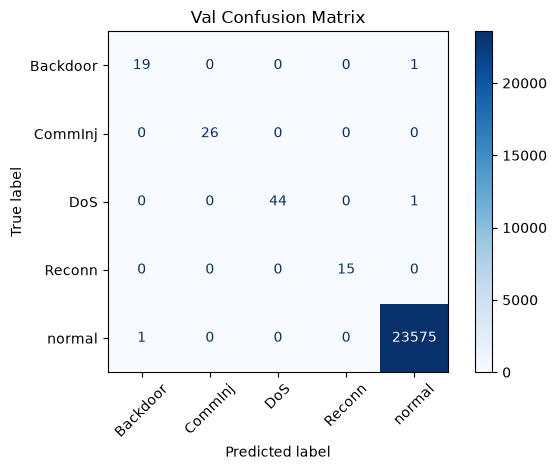

Test set
              precision    recall  f1-score   support

    Backdoor     0.8837    0.9744    0.9268        39
     CommInj     0.9808    1.0000    0.9903        51
         DoS     1.0000    1.0000    1.0000        91
      Reconn     1.0000    0.9355    0.9667        31
      normal     0.9999    0.9999    0.9999     47152

    accuracy                         0.9998     47364
   macro avg     0.9729    0.9819    0.9767     47364
weighted avg     0.9998    0.9998    0.9998     47364

Precision: 0.9729
Recall: 0.9819
F1 score: 0.9767
PR-AUC: 0.9879


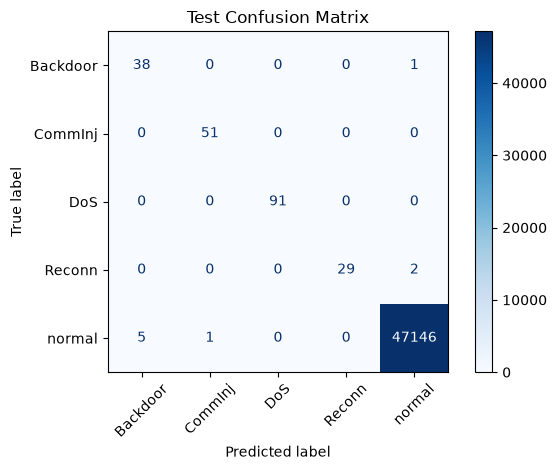

In [12]:
evaluate_model(best_clf, X_val, y_val, 'Val')
evaluate_model(best_clf, X_test, y_test, 'Test')

In [ ]:
os.makedirs('../../models', exist_ok=True)
joblib.dump(best_clf, '../../models/xgboost.joblib')

# what is not yet done

tuning of threshold
model explainability
